# 2. Insolation

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

## Part 1

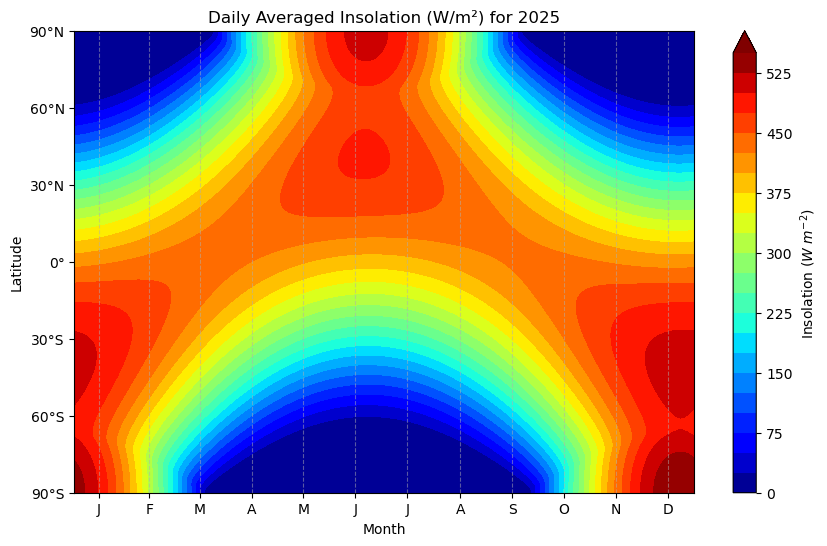

In [144]:
def calculate_insolation_for_year(
    year=2025, e=0.017, omega_deg=282.95, gamma_deg=23.44):
    """
    Calculates the diurnally averaged insolation for a given year and orbital 
    parameters.
    
    This function follows the step-by-step procedure outlined in the 
    Insolation Calculation box in the Physics of Earth's Climate chapter 3, 
    page 95. It uses orbital parameters to calculate the daily variation of 
    insolation over all latitudes for a full year.

    Args:
        year (int): The calendar year for the calculation. This is used to 
                    determine leap years. Defaults to 2025.
        e (float): Eccentricity of Earth's orbit. Defaults to 0.017, the value 
                   for 1/1/2000 from Table 3.1.
        omega_deg (float): Longitude of perihelion in degrees. Defaults to 
                           282.95, the value for 1/1/2000 from Table 3.1.
        gamma_deg (float): Obliquity of Earth's spin axis in degrees. Defaults 
                           to 23.44, the value for 1/1/2000 from Table 3.1.

    Returns:
        tuple: A tuple containing four elements:
            - day_of_year (np.ndarray): 1D array of day numbers.
            - latitudes_deg (np.ndarray): 1D array of latitudes from -90 to 90
                                          degrees.
            - insolation_grid (np.ndarray): 2D array (latitudes x days) holding 
                                            the calculated diurnally averaged 
                                            insolation in W/m\u00B2.
            - days_in_year (int): The total number of days in the given year.
    """

    # -------------------- Define Constants and Parameters --------------------
    S0 = 1362.0  # Total Solar Irradiance (W/m^2)
    ds = 1.000   # Semi-major axis (in AU)
    Ya = 365.26  # Anomalistic year (days)

    # Convert angles from degrees to radians for numpy functions
    omega = np.radians(omega_deg) # Longitude of perihelion 
    gamma = np.radians(gamma_deg) # Obliquity 

    # Check for leap year
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    days_in_year = 366 if is_leap else 365
    
    # March 21 is day 80 in a non-leap year, 81 in a leap year
    day_of_vernal_equinox = 81 if is_leap else 80

    # Create arrays for calculation
    # 't_days' is days since vernal equinox, our reference time
    day_of_year = np.arange(1, days_in_year + 1)
    t_days = day_of_year - day_of_vernal_equinox

    latitudes_deg = np.linspace(-90, 90, 181)
    latitudes_rad = np.radians(latitudes_deg)

    # 2D array to store results: rows=latitude, cols=day_of_year
    insolation_grid = np.zeros((len(latitudes_rad), len(t_days)))

    # ---------------- Calculate Parameters (Steps from p. 95) ----------------
    # Calculate Mean Anomaly at Vernal Equinox (Mv0) -- Equation 3.11
    beta = (1 - e**2)**0.5
    Mv0 = -omega + (e + e**3 / 4) * (1 + beta) * np.sin(omega) \
          - (1/2) * e**2 * (1/2 + beta) * np.sin(2 * omega) \
          + (1/4) * e**3 * (1/3 + beta) * np.sin(3 * omega)

    # Step 1: Calculate Mean Anomaly M(t) for all days -- Equation 3.10
    M = (2 * np.pi * t_days / Ya) + Mv0

    # Step 2: Calculate True Anomaly A(t) (to 3rd order) -- Equation 3.8
    A = M + (2 * e - e**3 / 4) * np.sin(M) \
        + (5 / 4) * e**2 * np.sin(2 * M) \
        + (13 / 12) * e**3 * np.sin(3 * M)

    # Step 3: Calculate Earth-Sun distance d(t) -- Equation 3.1
    d_au = ds * (1 - e**2) / (1 + e * np.cos(A))

    # Step 4: Get Solar Longitude Ls(t) -- Equation 3.9
    Ls = A + omega

    # Step 5: Calculate Declination Angle delta(t) -- Equation 3.16
    delta = np.sin(gamma) * np.sin(Ls)

    # ------------ Loop through latitudes to complete calculations ------------
    for i, phi in enumerate(latitudes_rad):
        # Step 6: Calculate Sunrise/Sunset Hour Angle (eta_d) -- Equation 3.19
        tan_phi = np.tan(phi)
        tan_delta = np.tan(delta)
        cos_eta_d = -tan_phi * tan_delta
        
        # Clamp values for polar day/night
        eta_d = np.arccos(np.clip(cos_eta_d, -1.0, 1.0))

        # Step 7: Calculate Diurnally Averaged Cosine of Zenith Angle 
        # -- Equation 3.20
        cos_theta_bar = (1 / np.pi) * (eta_d * np.sin(phi) * np.sin(
            delta) + np.cos(phi) * np.cos(delta) * np.sin(eta_d))

        # Step 8: Calculate Diurnally Averaged Insolation F -- Pg. 95
        S = S0 * (ds / d_au)**2
        F = S * cos_theta_bar
        
        insolation_grid[i, :] = F

    return day_of_year, latitudes_deg, insolation_grid, days_in_year

# ------------------------- Run Calculation and Plot -------------------------
# We'll use the orbital parameters from 1/1/2025 from Table 3.1
# Orbital parameters vary very slowly over thousands of years (Milankovitch 
# cycles), but the change from 2000 to 2025 is negligible for our purposes.
day_of_year, lats, insolation, days_in_year = calculate_insolation_for_year()

def setup_month_ticks(ax, days_in_year):
    """Helper to add month ticks to a daily insolation plot."""
    month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    if days_in_year == 366:
        month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    else:
        month_days = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    month_centers = np.cumsum(month_days) - month_days / 2.0
    ax.set_xlabel('Month')
    ax.set_xticks(month_centers, month_names)
    ax.set_yticks([-90, -60, -30, 0, 30, 60, 90], 
                  ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', 
                   '30\u00B0N', '60\u00B0N', '90\u00B0N'])
    ax.set_ylabel('Latitude')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.figure(figsize=(10, 6))
# Found insolation levels for contouring using np.max and np.min
levels = np.arange(0, 551, 25) 
# Plotting with contourf, similar to Fig 3.7
cf = plt.contourf(
    day_of_year, lats, insolation, levels=levels, cmap='jet', extend='max')
cbar = plt.colorbar(cf)
setup_month_ticks(plt.gca(), days_in_year)
cbar.set_label('Insolation ($W~m^{-2}$)')
plt.title('Daily Averaged Insolation (W/m\u00B2) for 2025')
plt.grid(axis='x', linestyle='--', alpha=0.5)

## Part 2

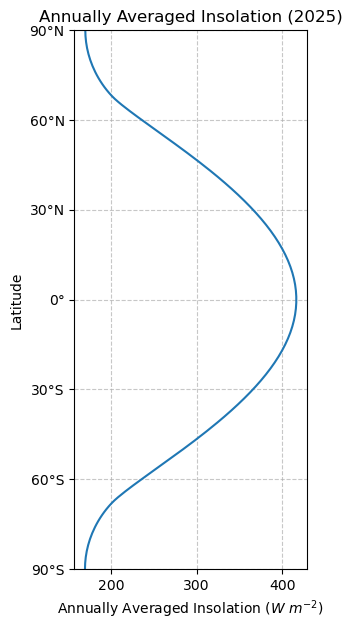

In [ ]:
# Average over the time axis (axis=1) of the insolation grid
annual_avg_insolation = np.mean(insolation, axis=1)

# Plot
plt.figure(figsize=(3, 7)) # Dimensions similar to Fig 3.7
plt.plot(annual_avg_insolation, lats)
plt.xlabel('Annually Averaged Insolation ($W~m^{-2}$)')
plt.ylabel('Latitude')
plt.title('Annually Averaged Insolation (2025)')
plt.yticks([-90, -60, -30, 0, 30, 60, 90], 
           ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
            '60\u00B0N', '90\u00B0N'])
plt.ylim(-90, 90)
plt.grid(True, linestyle='--', alpha=0.7)

## Part 3

In [145]:
# Calculate insolation with omega shifted by 180 degrees
_, _, insolation_new, _ = \
    calculate_insolation_for_year(omega_deg=282.95 + 180.0)

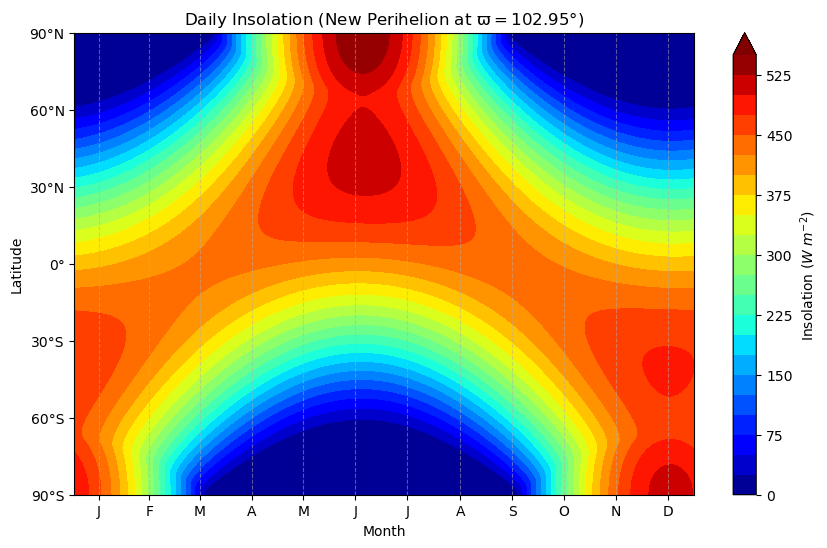

In [147]:
# Daily Insolation with New Perihelion
plt.subplots(figsize=(10, 6))
plt.title('Daily Insolation (New Perihelion at \u03D6$ = 102.95\degree$)')
levels = np.arange(0, 551, 25)
cf = plt.contourf(day_of_year, lats, insolation_new, levels=levels, cmap='jet', extend='max')
plt.colorbar(cf, label='Insolation ($W~m^{-2}$)')
setup_month_ticks(plt.gca(), days_in_year)

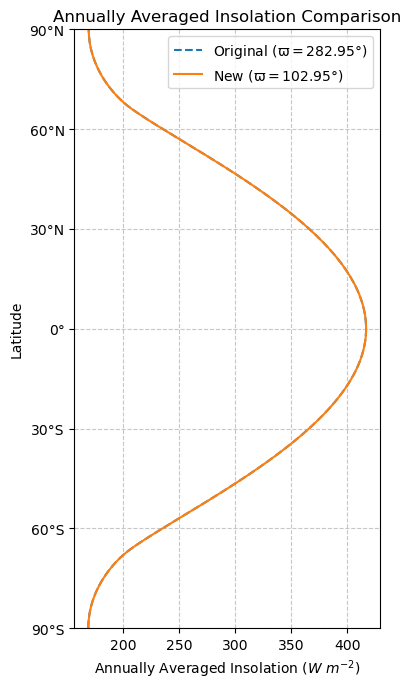

In [ ]:
# Annual Average (Original vs. New)
annual_avg_original = np.mean(insolation, axis=1)
annual_avg_new = np.mean(insolation_new, axis=1)

plt.subplots(figsize=(4, 7))
plt.plot(annual_avg_original, lats, 
         label='Original (\u03D6$ = 282.95\degree$)', linestyle='--')
plt.plot(annual_avg_new, lats, label='New (\u03D6$ = 102.95\degree$)', 
         linestyle='-')
plt.xlabel('Annually Averaged Insolation ($W~m^{-2}$)')
plt.ylabel('Latitude')
plt.yticks([-90, -60, -30, 0, 30, 60, 90], 
           ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
            '60\u00B0N', '90\u00B0N'])
plt.ylim(-90, 90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.title('Annually Averaged Insolation Comparison')
plt.tight_layout()

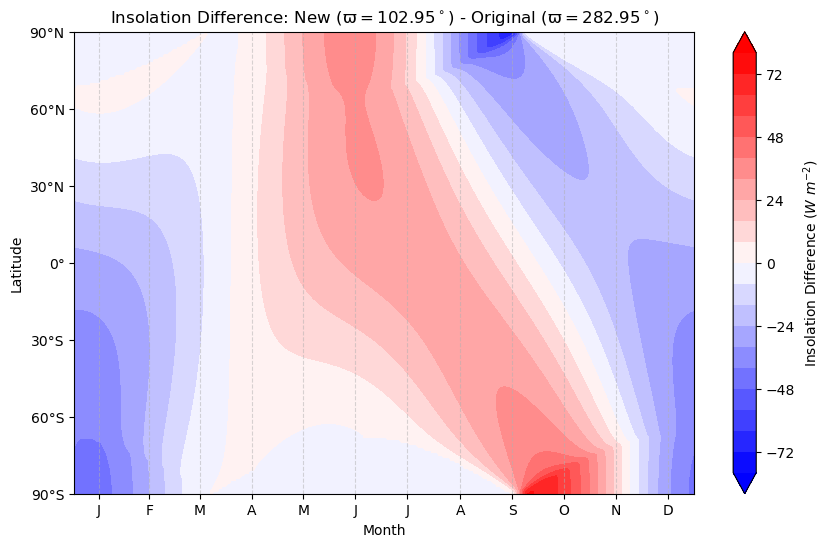

In [ ]:
# Daily Insolation Difference (New - Original)
plt.subplots(figsize=(10, 6))
plt.title('Insolation Difference: New (\u03D6$ = 102.95\degree$) - \
Original (\u03D6$ = 282.95\degree$)')
# Use a diverging colormap (Blue-White-Red) and center it on zero
diff_levels = np.linspace(-80, 80, 21)
cf3 = plt.contourf(day_of_year, lats, insolation_new - insolation, 
                   levels=diff_levels, cmap='bwr', extend='both')
plt.colorbar(cf3, label='Insolation Difference ($W~m^{-2}$)')
setup_month_ticks(plt.gca(), days_in_year)

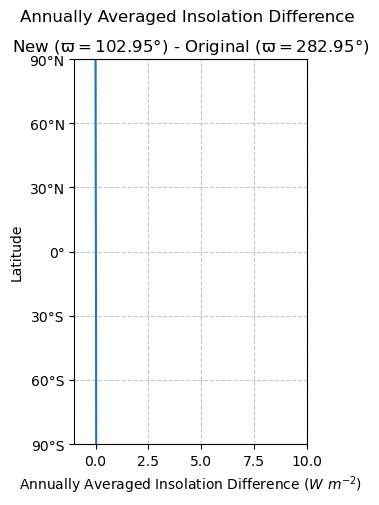

In [149]:
# Annual Average Insolation Difference (New - Original)
plt.figure(figsize=(3, 5))
plt.plot(np.mean(insolation_new - insolation, axis=1), lats)
plt.suptitle('Annually Averaged Insolation Difference')
plt.title('New (\u03D6$ = 102.95\degree$) - Original (\u03D6$ = 282.95\degree$)')
plt.xlabel('Annually Averaged Insolation Difference ($W~m^{-2}$)')
plt.ylabel('Latitude')
plt.yticks([-90, -60, -30, 0, 30, 60, 90], 
           ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
            '60\u00B0N', '90\u00B0N'])
plt.ylim(-90, 90)
plt.xlim(-1, 10)
plt.grid(True, linestyle='--', alpha=0.7)

## Part 4

In [151]:
# Calculate new low-obliquity insolation
_, _, insolation_new_obliquity, _ = \
    calculate_insolation_for_year(gamma_deg=20.0)

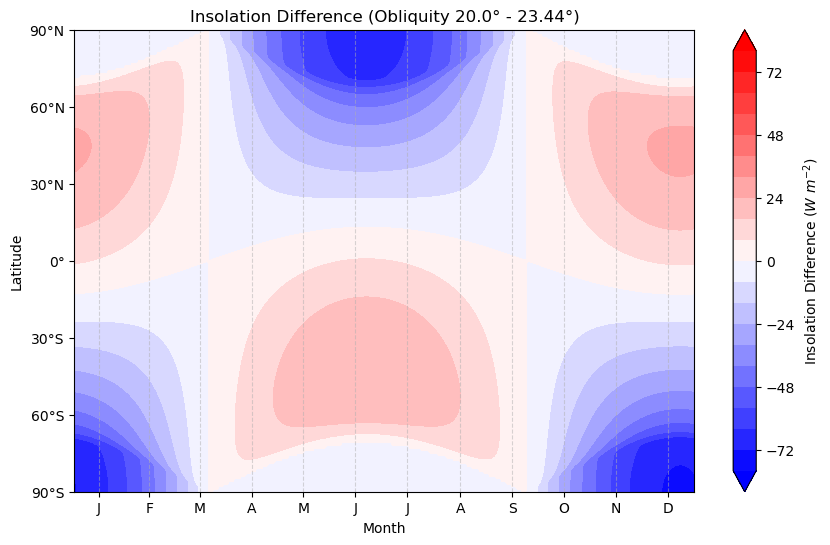

In [152]:
difference_daily_obliquity = insolation_new_obliquity - insolation
plt.subplots(figsize=(10, 6))
plt.title('Insolation Difference (Obliquity 20.0\u00B0 - 23.44\u00B0)')
diff_levels = np.linspace(-80, 80, 21) 
cf = plt.contourf(day_of_year, lats, difference_daily_obliquity, 
                  levels=diff_levels, cmap='bwr', extend='both')
plt.colorbar(cf, label='Insolation Difference ($W~m^{-2}$)')
setup_month_ticks(plt.gca(), days_in_year)

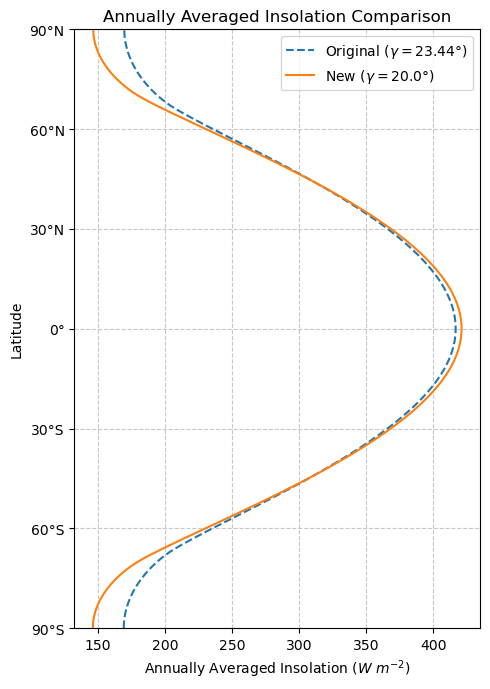

In [153]:
# Annual Average (Original vs. New)
annual_avg_original = np.mean(insolation, axis=1)
annual_avg_new_obliquity = np.mean(insolation_new_obliquity, axis=1)

fig2, ax2 = plt.subplots(figsize=(5, 7))
ax2.plot(annual_avg_original, lats, label='Original ($\gamma = 23.44\degree$)', 
         linestyle='--')
ax2.plot(annual_avg_new_obliquity, lats, label='New ($\gamma = 20.0\degree$)', 
         linestyle='-')
ax2.set_xlabel('Annually Averaged Insolation ($W~m^{-2}$)')
ax2.set_ylabel('Latitude')
ax2.set_yticks([-90, -60, -30, 0, 30, 60, 90], 
               ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
                '60\u00B0N', '90\u00B0N'])
ax2.set_ylim(-90, 90)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()
ax2.set_title('Annually Averaged Insolation Comparison')
fig2.tight_layout()

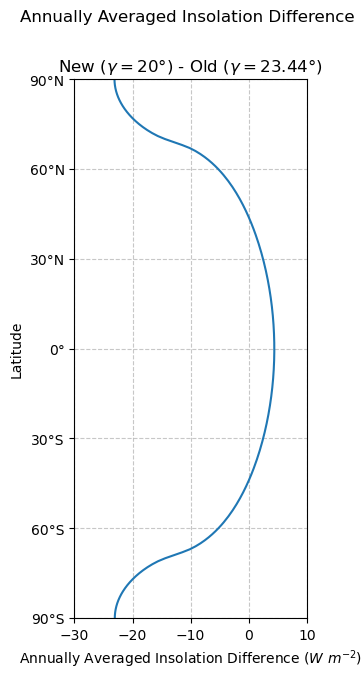

In [ ]:
# Annual Average Insolation Difference (New - Original)
plt.figure(figsize=(3, 7))
plt.plot(np.mean(insolation_new_obliquity - insolation, axis=1), lats)
plt.xlabel('Annually Averaged Insolation Difference ($W~m^{-2}$)')
plt.ylabel('Latitude')
plt.title('New ($\gamma = 20\degree$) - Old ($\gamma = 23.44\degree$)')
plt.suptitle('Annually Averaged Insolation Difference')
plt.yticks([-90, -60, -30, 0, 30, 60, 90], 
           ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
            '60\u00B0N', '90\u00B0N'])
plt.ylim(-90, 90)
plt.xlim(-30, 10)
plt.grid(True, linestyle='--', alpha=0.7)

## Part 6

In [156]:
# Calculating new high-obliquity insolation
_, _, insolation_new_obliquity_60, _ = \
    calculate_insolation_for_year(gamma_deg=60.0)

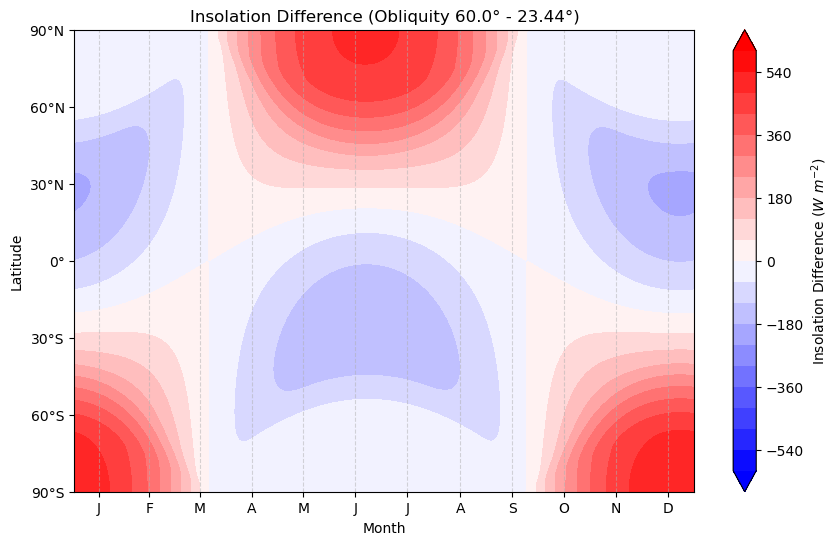

In [157]:
# Daily Insolation Difference (New - Original)
plt.subplots(figsize=(10, 6))
plt.title('Insolation Difference (Obliquity 60.0\u00B0 - 23.44\u00B0)')
# The changes are much more extreme now
diff_levels = np.linspace(-600, 600, 21) 
cf = plt.contourf(day_of_year, lats, insolation_new_obliquity_60 - insolation, 
                   levels=diff_levels, cmap='bwr', extend='both')
plt.colorbar(cf, label='Insolation Difference ($W~m^{-2}$)')
setup_month_ticks(plt.gca(), days_in_year)

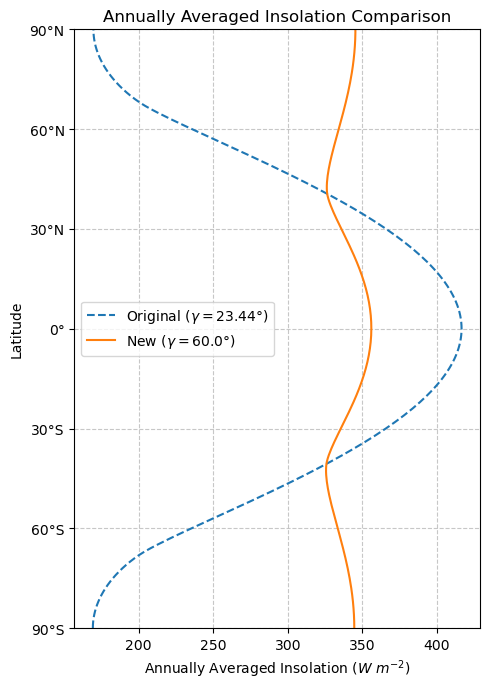

In [159]:
# Annual Average (Original vs. New)
annual_avg_original = np.mean(insolation, axis=1)
annual_avg_new_obliquity_60 = np.mean(insolation_new_obliquity_60, axis=1)

fig2, ax2 = plt.subplots(figsize=(5, 7))
ax2.plot(annual_avg_original, lats, label='Original ($\gamma = 23.44\degree$)', 
         linestyle='--')
ax2.plot(annual_avg_new_obliquity_60, lats, 
         label='New ($\gamma = 60.0\degree$)', linestyle='-')
ax2.set_xlabel('Annually Averaged Insolation ($W~m^{-2}$)')
ax2.set_ylabel('Latitude')
ax2.set_yticks([-90, -60, -30, 0, 30, 60, 90], 
               ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
                '60\u00B0N', '90\u00B0N'])
ax2.set_ylim(-90, 90)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()
ax2.set_title('Annually Averaged Insolation Comparison')
fig2.tight_layout()

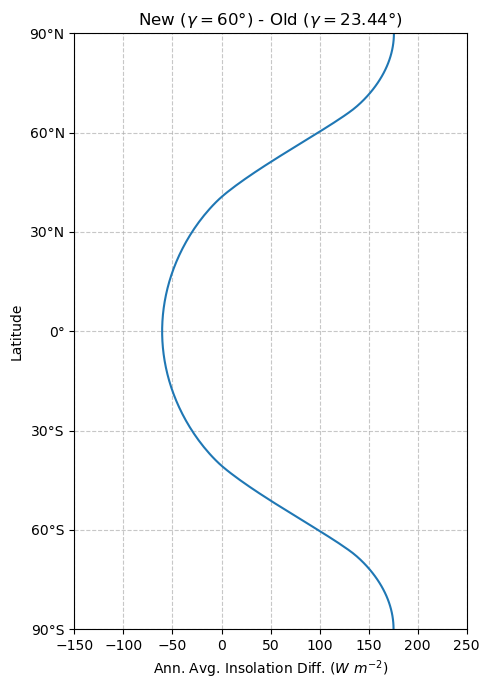

In [160]:
# Annual Average Insolation Difference (New - Original)
plt.figure(figsize=(5, 7))
plt.plot(np.mean(insolation_new_obliquity_60 - insolation, axis=1), lats)
plt.xlabel('Ann. Avg. Insolation Diff. ($W~m^{-2}$)')
plt.ylabel('Latitude')
plt.title('New ($\gamma = 60\degree$) - Old ($\gamma = 23.44\degree$)')
plt.yticks([-90, -60, -30, 0, 30, 60, 90], 
           ['90\u00B0S', '60\u00B0S', '30\u00B0S', '0\u00B0', '30\u00B0N', 
            '60\u00B0N', '90\u00B0N'])
plt.ylim(-90, 90)
plt.xlim(-150, 250) # Adjusted limits for the new range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()